# Refresher: random numbers

This notebook introduces random number generation in Python, how we can sample from probability distributions, and use it for Monte Carlo error propagation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

We start by creating an instance of the NumPy random number generator. You can set the `seed` to another positive integer to create a different, but still reproducible, sequence of random numbers.

In [2]:
rng = np.random.default_rng(seed=1)
print(rng)

Generator(PCG64)


In [3]:
# General settings
n_random = 1000
plt.rcParams["figure.figsize"] = (5, 3)

## A note on "random" numbers

Random number generators are actually pseudo-random number generators, so sequences that behave like random numbers, even though they are produced by a deterministic algorithm. Using the same seed of the generator will always result in the same sequence of random numbers. This is useful for bug fixing, but more importantly for reproducing scientific results, such as a Monte Carlo simulation.

## The uniform distribution

Random numbers are often used for drawing random samples from a probability distribution. The simplest case is a uniform distribution, so every value in a chosen interval is equally likely.

Here we draw `n_random` values between `low=-5` and `high=5`.

In [4]:
low = -5.0
high = 5.0
x = rng.uniform(low=low, high=high, size=n_random)
print(x[:10])

[ 0.11821625  4.50463696 -3.55840387  4.48649447 -1.88168548 -0.76673551
  3.27702594 -0.90800864  0.49593688 -4.72440887]


A histogram should look approximately flat. Because the draws are random, the bin counts are not identical, but they should fluctuate around the expected mean count per bin.

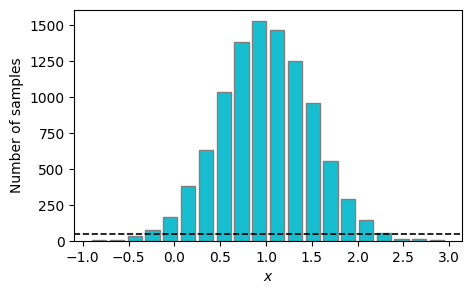

In [ ]:
n_bins = 20
expected_per_bin = n_random / n_bins

plt.hist(x, bins=n_bins, edgecolor="gray", rwidth=0.8, color='tab:cyan')
plt.axhline(expected_per_bin, color="black", linestyle="--", linewidth=1.2)
plt.xlabel(r"$x$")
plt.ylabel("Number of samples")
plt.minorticks_on()
plt.show()

### Probability density distributions

We can normalize the histogram by setting `density=True`, such that the total area of the histogram will be 1. For a uniform distribution between `low` and `high`, the probability density is

$$
p(x) = \frac{1}{\mathrm{high}-\mathrm{low}}.
$$

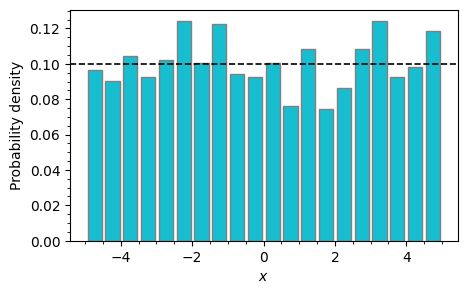

In [6]:
prob_density = 1.0 / (high - low)

counts, bin_edges, _ = plt.hist(x, bins=n_bins, density=True, edgecolor="gray", rwidth=0.8, color='tab:cyan')
plt.axhline(prob_density, color="black", linestyle="--", linewidth=1.2)
plt.xlabel("$x$")
plt.ylabel("Probability density")
plt.minorticks_on()
plt.show()

Let's check if the integral of the histogram is indeed 1.

In [7]:
int_hist = np.sum((bin_edges[1:]-bin_edges[:-1]) * counts)
print(f"Histogram integral = {int_hist:.2f}")

Histogram integral = 1.00


## The normal distribution

The normal (Gaussian) distribution is one of the most important distributions in science. It often arises due to the [central limit theorem](https://en.wikipedia.org/wiki/Central_limit_theorem), and is commonly assumed when performing standard error propagation. The normal distribution is defined by a mean $\mu$ and a standard deviation $\sigma$:

$$p(x) = \frac{1}{\sqrt{ 2 \pi \sigma^2 }} e^{ - \frac{ (x - \mu)^2 } {2 \sigma^2} }$$

We draw from this distribution by using the `normal` method of the random number generator:

In [8]:
mu = 1.0
sigma = 0.5

x = rng.normal(loc=mu, scale=sigma, size=n_random)

Let's compare the histogram with the expected analytical curve. We calculate the latter with 200 points between $\mu - 4\sigma$ and $\mu + 4\sigma$.

In [9]:
x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
y_norm = (1.0 / np.sqrt(2*np.pi*sigma**2)) * np.exp(-(x_norm - mu)**2 / (2*sigma**2))

We set again `density=True` to make sure that the histogram is normalized to a probability density function.

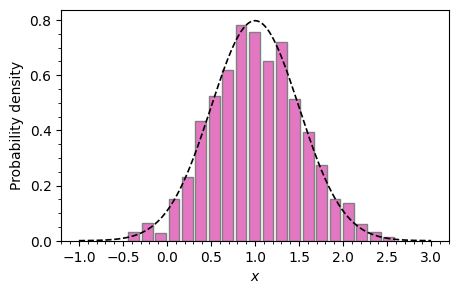

In [10]:
plt.hist(x, bins=n_bins, density=True, edgecolor="gray", rwidth=0.8, color='tab:pink')
plt.plot(x_norm, y_norm, color="black", linestyle="--", linewidth=1.2)
plt.xlabel(r"$x$")
plt.ylabel("Probability density")
plt.minorticks_on()
plt.show()

## Effect of sample size

Histograms will look noisy with a small number of random samples. With more draws, they approach the expected distribution more closely.

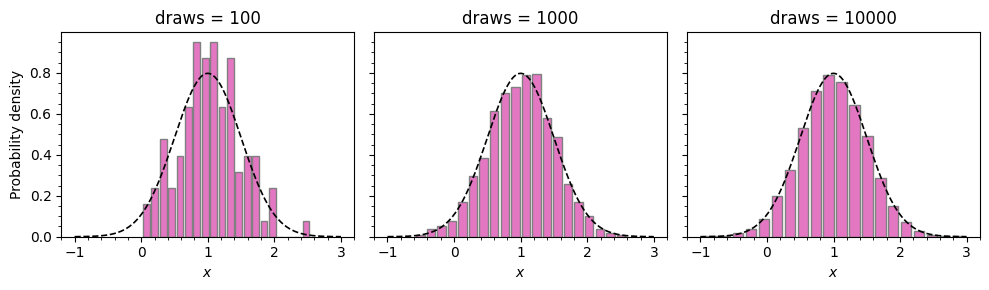

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

for ax_idx, n_draws in enumerate([100, 1000, 10000]):
    x = rng.normal(loc=mu, scale=sigma, size=n_draws)
    axs[ax_idx].hist(x, bins=20, density=True, edgecolor="gray", rwidth=0.8, color='tab:pink')

    x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    y_norm = (1.0 / np.sqrt(2*np.pi*sigma**2)) * np.exp(-(x_norm - mu)**2 / (2*sigma**2))
    axs[ax_idx].plot(x_norm, y_norm, color="black", linestyle="--", linewidth=1.2)

    axs[ax_idx].set_title(f"draws = {n_draws}")
    axs[ax_idx].set_xlabel(r"$x$")
    axs[ax_idx].minorticks_on()

axs[0].set_ylabel("Probability density")

plt.tight_layout()
plt.show()

We see in the figure that the histograms become smoother as the number of draws increases.

In this example, the bin widths also slightly change between panels, because the sampled tails of the distribution extend farther when more draws are taken.

## Error propagation with random numbers

### The Monte Carlo approach

The standard error propagation that you are familiar with is a powerful method, but it typically assumes that:

- uncertainties are reasonably small
- errors are approximately normal, so described by their variance
- the function can be locally linearized 

Monte Carlo simulations provide a more general approach for error propagation. These are the steps to take:

1. draw many random realizations of the measured quantity
2. apply your calculation to each realization
3. inspect the resulting distribution
4. quote uncertainties based on the percentiles

This is especially useful when the transformation is nonlinear, so the output distribution may become asymmetric.

### Example: counts to magnitudes

Suppose a star has a measured flux, in detector counts, of:

$$
c = 35 \pm 15
$$

and recall that the magnitude is defined as

$$
m = -2.5\log_{10} c.
$$

Because the logarithm is nonlinear, symmetric uncertainties in counts do not necessarily become symmetric uncertainties in magnitude.

We start by computing Monte Carlo realizations of the flux by drawing 1000 samples from a normal distribution with mean equal to the measured flux and standard deviation equal to the measurement uncertainty.

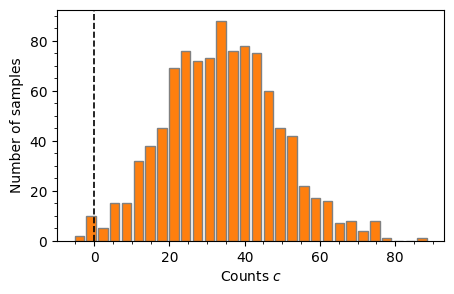

In [12]:
n_draws = 1000
c_mean = 35.0
c_sigma = 15.0

mc_counts = rng.normal(loc=c_mean, scale=c_sigma, size=n_draws)

plt.hist(mc_counts, bins=30, edgecolor="gray", rwidth=0.8, color="tab:orange")
plt.axvline(0, color="black", linestyle="--", linewidth=1.2)
plt.xlabel(r"Counts $c$")
plt.ylabel("Number of samples")
plt.minorticks_on()
plt.show()

A subtle point appears in the figure: some simulated count values are negative. This can happen if we model the measurement uncertainty with a normal distribution, even though physical counts can't be negative.

In [13]:
neg_frac = np.sum(mc_counts <= 0)/mc_counts.size
print(f"Fraction of draws with c <= 0 is {neg_frac:.3f}")

Fraction of draws with c <= 0 is 0.008


We will now calculate the magnitudes in a vectorized manner by propagating the Monte Carlo samples. We will exclude the non-physical values because $\log_{10}(c)$ is undefined for $c \le 0$.

In [14]:
mc_mag = -2.5 * np.log10(mc_counts[mc_counts > 0])

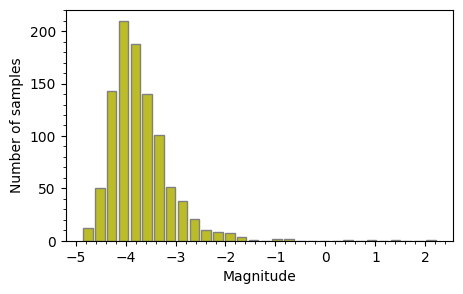

In [15]:
plt.hist(mc_mag, bins=30, edgecolor="gray", rwidth=0.8, color="tab:olive")
plt.xlabel("Magnitude")
plt.ylabel("Number of samples")
plt.minorticks_on()
plt.show()

This distribution is clearly not symmetric.

For comparison, if we apply standard linear error propagation to $m = -2.5 \log_{10} c$, we obtain

$$
\Delta m = \left|\frac{dm}{dc}\right| \Delta c
         = \frac{2.5}{\ln 10}\frac{\Delta c}{c}.
$$

In [16]:
mag_lin = -2.5 * np.log10(c_mean)
dmag_lin = 2.5 * c_sigma / (np.log(10.0) * c_mean)

print(f"Linear magnitude estimate: {mag_lin:.2f} ± {dmag_lin:.2f}")

Linear magnitude estimate: -3.86 ± 0.47


We can overplot that symmetric Gaussian approximation on the Monte Carlo result.

In [17]:
x_norm = np.linspace(-7, 0, 500)
y_norm = (1.0 / np.sqrt(2*np.pi*dmag_lin**2)) * np.exp(-(x_norm - mag_lin)**2 / (2*dmag_lin**2))

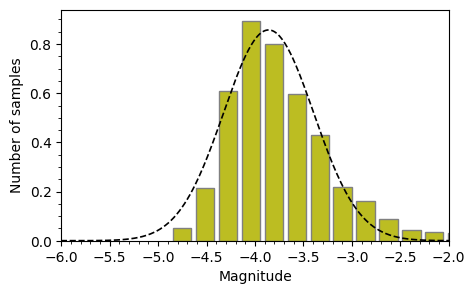

In [18]:
counts, bin_edges, _ = plt.hist(mc_mag, bins=30, density=True, edgecolor="gray", rwidth=0.8, color="tab:olive")
plt.plot(x_norm, y_norm, color="black", linestyle="--", linewidth=1.2)
plt.xlabel("Magnitude")
plt.ylabel("Number of samples")
plt.xlim(-6, -2)
plt.minorticks_on()
plt.show()

Clearly, a normal distribution is not a good approximation for the magnitudes, because the transformation of the Monte Carlo samples yields an asymmetric distribution of the magnitudes.

### Reporting asymmetric uncertainties

So how do we quote the uncertainty on this magnitude?

To answer that, we return to the Gaussian distribution, for which uncertainties are usually written as $\pm\sigma$. For a Gaussian distribution, 16% of the probability lies below $\mu - 1\sigma$, 50% below the median, and 84% below $\mu + 1\sigma$.

This means that the interval from $\mu-1\sigma$ to $\mu+1\sigma$ contains 68% of the probability, so the familiar 68% confidence interval. Likewise, the range from $-2\sigma$ to $+2\sigma$ contains 95% of the probability.

We can apply the same idea on the asymmetric distribution of the magnitudes:

In [19]:
q_list = [16, 50, 84]
mag_percentiles = np.percentile(mc_mag, q_list)
print(mag_percentiles)

[-4.22038766 -3.83656918 -3.24944833]


In [20]:
median = mag_percentiles[1]
minus = median - mag_percentiles[0]
plus = mag_percentiles[2] - median

print(f"Magnitude = {median:.4f} -{minus:.4f} +{plus:.4f}")

Magnitude = -3.8366 -0.3838 +0.5871


Let's plot again the distribution of magnitudes, but now combined with vertical lines at the 16th, 50th, and 84th percentiles.

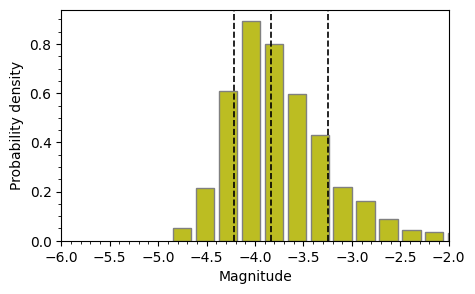

In [21]:
plt.hist(mc_mag, bins=30, density=True, edgecolor="gray", rwidth=0.8, color="tab:olive")

for i, item in enumerate(q_list):
    plt.axvline(mag_percentiles[i], color="black", linestyle="--", linewidth=1.2)

plt.xlabel("Magnitude")
plt.ylabel("Probability density")
plt.xlim(-6, -2)
plt.minorticks_on()
plt.show()

In the end, we would report the result in the following form:

$$
m = -4.3_{-0.3}^{+0.4}
$$

We can use the method for any complex error propagation.